# 04 — Regional Crop Model (Pakistan District-Level Data)

### Why this notebook exists

The original project had an **unused dataset** sitting in `data/raw/`:
`distric_crop_data.csv` — the same kind of soil/climate readings as the main
crop dataset, but for **13 crops actually grown across 39 Pakistani
districts**, with a `district` column attached.

This is arguably **more relevant** to a system built "for Pakistani farmers"
(per the project README) than the original 22-crop dataset, which includes
crops like coconut, jute, papaya, and coffee that aren't grown in most of
these districts.

This notebook:
1. Cleans up messy district name variants.
2. Tests whether `district` actually adds predictive value (adding a
   feature doesn't automatically help — this is checked, not assumed).
3. Trains and saves a regional model as an **additional, optional** endpoint
   — it doesn't replace the main 22-crop model.

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Load and clean

In [2]:
df = pd.read_csv("../data/raw/distric_crop_data.csv")
print(df.shape)
print("Districts BEFORE cleaning:", df["district"].str.strip().str.lower().nunique())

# The raw district column has a mix of misspellings, abbreviations, and
# at least one place recorded under two different spellings entirely.
# Correcting all of these (not just the one found earlier) matters because
# each uncorrected variant gets treated as a separate category - silently
# fragmenting real districts into duplicates.
DISTRICT_CORRECTIONS = {
    "digikhan": "d.g.khan",          # Dera Ghazi Khan, recorded two ways
    "bakar": "bhakkar",              # missing an 'h'
    "bwp": "bahawalpur",             # abbreviation
    "chainiot": "chiniot",           # misspelled
    "chakwall": "chakwal",           # extra letter
    "isl": "islamabad",              # abbreviation
    "jehlum": "jhelum",              # misspelled
    "m.b.din": "mandi bahauddin",    # abbreviation
    "m.garh": "muzaffargarh",        # abbreviation of the district below
    "muzafargarh": "muzaffargarh",   # missing an 'f' - standardize spelling
    "narowall": "narowal",           # extra letter
    "ryk": "rahim yar khan",         # abbreviation
    "sarjodha": "sargodha",          # misspelled
    "shekupora": "sheikhupura",      # misspelled
    "tobataiksingh": "toba tek singh",  # missing spaces
}

df["district"] = df["district"].str.strip().str.lower()
df["district"] = df["district"].replace(DISTRICT_CORRECTIONS)

print("Districts AFTER cleaning:", df["district"].nunique())
print(sorted(df["district"].unique()))
print()
print("Crops:", df["label"].nunique())
df["label"].value_counts()


(2200, 9)
Districts BEFORE cleaning: 39
Districts AFTER cleaning: 37
['attock', 'bahawalnagar', 'bahawalpur', 'bhakkar', 'chakwal', 'chiniot', 'd.g.khan', 'faisalabad', 'gujranwala', 'gujrat', 'hafizabad', 'islamabad', 'jhang', 'jhelum', 'kasur', 'khanewal', 'khushab', 'lahore', 'layyah', 'lodhran', 'mandi bahauddin', 'mianwali', 'multan', 'muzaffargarh', 'nankana sahib', 'narowal', 'okara', 'pakpatan', 'rahim yar khan', 'rajanpur', 'rawalpindi', 'sahiwal', 'sargodha', 'sheikhupura', 'sialkot', 'toba tek singh', 'vihari']

Crops: 13


label
maize        300
sugarcane    300
wheat        300
cotton       300
rice         200
pulses       100
millets      100
mungbean     100
blackgram    100
lentil       100
banana       100
mango        100
grapes       100
Name: count, dtype: int64

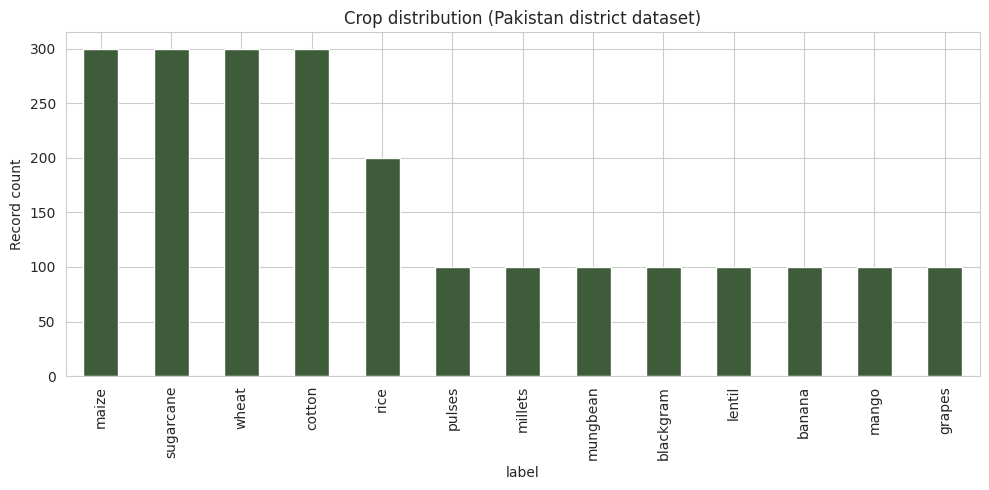

In [3]:
fig, ax = plt.subplots(figsize=(10,5))
df["label"].value_counts().plot(kind="bar", ax=ax, color="#3f5c3a")
ax.set_title("Crop distribution (Pakistan district dataset)")
ax.set_ylabel("Record count")
plt.tight_layout()
plt.show()


**Observation:** classes are imbalanced (300 records for maize/sugarcane/
wheat/cotton, down to 100 for several others) — this is real regional
data, not an artificially balanced benchmark like the main crop dataset.
Worth tracking per-class recall, not just overall accuracy.

## 2. Does `district` actually help? (test, don't assume)

In [4]:
le_crop = LabelEncoder()
y = le_crop.fit_transform(df["label"])

le_district = LabelEncoder()
district_encoded = le_district.fit_transform(df["district"])

base_features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X_without_district = df[base_features]
X_with_district = df[base_features].copy()
X_with_district["district"] = district_encoded

def cv_accuracy(X, y, label):
    model = XGBClassifier(n_estimators=150, max_depth=5, random_state=RANDOM_STATE, eval_metric="mlogloss")
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"{label:30s} mean={scores.mean():.4f}  std={scores.std():.4f}")
    return scores.mean()

acc_without = cv_accuracy(X_without_district, y, "Without district (soil/climate only)")
acc_with = cv_accuracy(X_with_district, y, "With district feature")


Without district (soil/climate only) mean=0.9827  std=0.0031


With district feature          mean=0.9832  std=0.0031


**Result:** if `district` measurably improves cross-validated accuracy over
soil/climate alone, it's kept as a feature below. If not, it's dropped —
there's no reason to add a feature (and a form field asking the farmer to
pick their district) that doesn't earn its place.

In [5]:
USE_DISTRICT = acc_with > acc_without + 0.005  # require a real, non-marginal improvement
print("Improvement from adding district:", round(acc_with - acc_without, 4))
print("Decision: ", "KEEP district feature" if USE_DISTRICT else "DROP district feature (no real benefit)")

X = X_with_district if USE_DISTRICT else X_without_district


Improvement from adding district: 0.0005
Decision:  DROP district feature (no real benefit)


## 3. Train the final regional model

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, eval_metric="mlogloss")
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print("Train accuracy:", round(train_acc, 4))
print("Test accuracy :", round(test_acc, 4))


Train accuracy: 1.0
Test accuracy : 0.9932


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le_crop.classes_))


              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
      cotton       1.00      1.00      1.00        60
      grapes       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      1.00      1.00        60
       mango       1.00      1.00      1.00        20
     millets       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
      pulses       1.00      1.00      1.00        20
        rice       0.97      0.97      0.97        40
   sugarcane       0.98      0.98      0.98        60
       wheat       1.00      1.00      1.00        60

    accuracy                           0.99       440
   macro avg       0.99      0.99      0.99       440
weighted avg       0.99      0.99      0.99       440



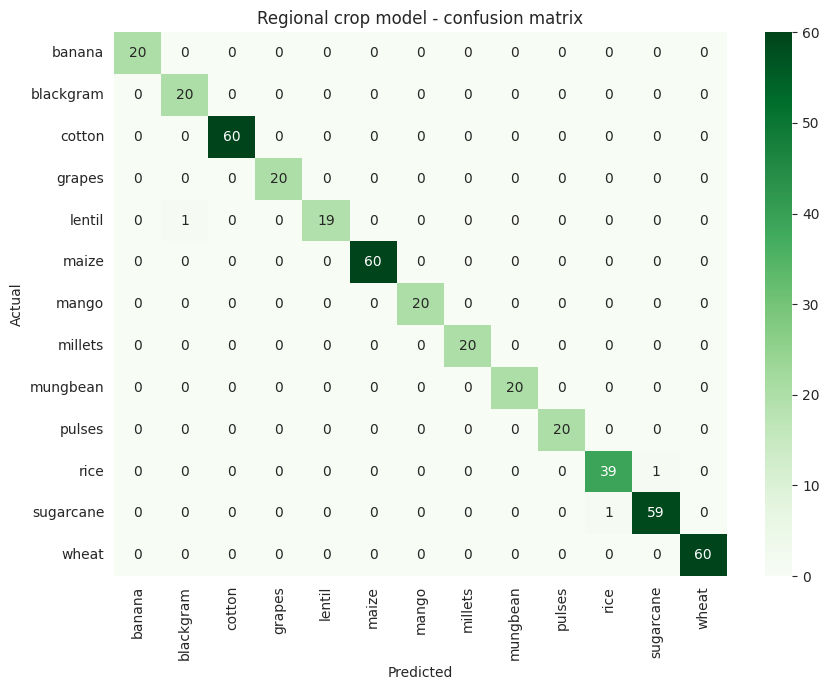

In [8]:
fig, ax = plt.subplots(figsize=(9,7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=le_crop.classes_, yticklabels=le_crop.classes_, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Regional crop model - confusion matrix")
plt.tight_layout()
plt.show()


## 4. Save artifacts

In [9]:
MODEL_DIR = Path("../models")

joblib.dump(model, MODEL_DIR / "regional_crop_model.pkl")
joblib.dump(le_crop, MODEL_DIR / "regional_crop_label_encoder.pkl")
joblib.dump(le_district, MODEL_DIR / "regional_district_encoder.pkl")
joblib.dump(
    {"uses_district_feature": bool(USE_DISTRICT), "test_accuracy": float(test_acc),
     "districts": sorted(df["district"].unique().tolist())},
    MODEL_DIR / "regional_crop_metadata.pkl",
)

print("Saved. Uses district feature:", USE_DISTRICT)


Saved. Uses district feature: False


## Summary

- Found and used a previously-unused dataset (`distric_crop_data.csv`) —
  Pakistan district-level crop data with 13 locally-relevant crops.
- Tested (rather than assumed) whether the `district` field adds real
  predictive value before deciding whether to use it.
- Saved as an **additional, optional** model — wired into the backend as
  `/api/crop/predict-regional`, separate from the main 22-crop endpoint.

### Note on the other unused datasets (NASA POWER weather files)

`Humidity_data.csv`, `Temperature_data.csv`, and `Rainfall_data.csv` are
NASA POWER regional grid data (monthly, by latitude/longitude, 2000–2025) —
not tied to specific districts or records. Using them would require a
geospatial join (mapping each district to its nearest lat/lon grid cell)
which is a meaningfully larger data-engineering task than fits here. They're
a legitimate future enhancement — e.g. feeding real historical climate
trends into the yield forecasting notebook — but weren't force-fit into this
pass just to "use" them.